In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv


# Importação do dataset: Carregamento dos Dados



In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### **O que foi feito?**

O projeto foi iniciado com a importação da biblioteca Pandas, Numpy, SVC, StandardScaler e Accuracy.


# Tratamento de Dados

In [3]:
df = df.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')

df['diagnosis'] = df['diagnosis'].replace({'M': 1, 'B': 0})

df.head()

/tmp/ipykernel_17/935496860.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['diagnosis'] = df['diagnosis'].replace({'M': 1, 'B': 0})


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### **O que foi feito?**

Foi realizado o tratamento de dados para garanti que o **SVM** receba apenas informações relevantes para o diagnóstico.

1. **Remoção de Colunas Irrelevantes:** Excluímos a coluna `id` (identificador único) e a `Unnamed: 32` (coluna residual de importação com valores nulos). Manter o `id` poderia causar um erro de lógica, fazendo o modelo "decorar" pacientes em vez de aprender padrões celulares.
2. **Transformação do Alvo (Target):** Convertemos a variável categórica `diagnosis` para o formato numérico binário:
   * **Maligno (M) → 1**
   * **Benigno (B) → 0**


# Separação de Variáveis e Divisão em Treino e Teste


In [4]:
X = df.drop('diagnosis', axis=1) 
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dados originais: {X.shape}")
print(f"Dados de Treino: {X_train.shape}")
print(f"Dados de Teste: {X_test.shape}")

Dados originais: (569, 30)
Dados de Treino: (398, 30)
Dados de Teste: (171, 30)


### **O que foi feito?**

Com os dados limpos, foi preparado o ambiente para o aprendizado supervisionado. 

1. **Features (X):** Todas as características físicas medidas das células (raio, textura, área, etc.), excluindo a coluna de diagnóstico.
2. **Target (y):** A variável que queremos que o modelo aprenda a prever


Foi dividido o conjunto total em **70% para treinamento** e **30% para teste**. O `random_state=42` garante que essa divisão seja sempre a mesma toda vez que rodarmos o código.

# Padronização de Atributos

In [5]:
scaler = StandardScaler()

O `StandardScaler` é essencial para o **SVM**, pois evita que o cálculo do hiperplano seja distorcido por variáveis com grandes amplitudes térmicas ou numéricas, como a Glicose.

In [6]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Exemplo dos dados escalonados (primeira linha):")
print(X_train_scaled[0])

Exemplo dos dados escalonados (primeira linha):
[-0.12348985 -0.29680142 -0.17050713 -0.20861569 -1.2016799  -0.7731696
 -0.76231194 -0.93324109 -1.22994935 -0.94816603 -0.53359339 -0.86028757
 -0.61678096 -0.39177533 -1.35556152 -0.52503193 -0.4817033  -0.97940018
 -0.88459317 -0.68548672 -0.19761978 -0.5067476  -0.30791001 -0.27357592
 -1.50742388 -0.44926047 -0.57223884 -0.84082156 -0.8563616  -0.76574773]


### **O que foi feito?**


1. **Ajuste e Treino (`fit_transform`):** O computador olha para os dados de treino, descobre a média e o desvio padrão de cada coluna e já aplica a escala de uma vez.
2. **Transformação do Teste (`transform`):** Usamos a "régua" que o modelo aprendeu no treino para transformar os dados de teste.


Com isso, todos os nossos dados estão na mesma escala, agora o SVM não ira se confundir com os números grandes.

# Treinamento dos Modelos com Dados Padronizados

In [7]:
modelo_linear = SVC(kernel='linear', C=1.0)
modelo_linear.fit(X_train_scaled, y_train)

modelo_rbf = SVC(kernel='rbf', C=1.0)
modelo_rbf.fit(X_train_scaled, y_train)

print("--- DESEMPENHO: KERNEL LINEAR ---")
print(classification_report(y_test, modelo_linear.predict(X_test_scaled)))

print("\n--- DESEMPENHO: KERNEL RBF ---")
print(classification_report(y_test, modelo_rbf.predict(X_test_scaled)))

--- DESEMPENHO: KERNEL LINEAR ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       108
           1       0.97      0.97      0.97        63

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171


--- DESEMPENHO: KERNEL RBF ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       108
           1       0.97      0.97      0.97        63

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



### **O que foi feito?**

Foi instanciado e treinado doi modelos de **SVM** para comparar qual se adapta melhor à fronteira de decisão deste dataset de câncer.

1. **Kernel Linear:** Tenta separar as classes através de um hiperplano reto
2. **Kernel RBF (Radial Basis Function):** Utiliza uma base radial para criar fronteiras curvas e complexas.

Foi utilizado o `classification_report` para avaliar as métricas de:
* **Precision (Precisão):** Qualidade das previsões positivas.
* **Recall (Sensibilidade):** Capacidade de encontrar todos os casos reais de câncer.
* **F1-Score:** O equilíbrio entre as duas métricas acima.

##  O Fator de Regularização (C)

In [8]:
modelo_c_alto = SVC(kernel='rbf', C=10.0) 
modelo_c_alto.fit(X_train_scaled, y_train)

print("--- DESEMPENHO: RBF com C=10.0 ---")
print(classification_report(y_test, modelo_c_alto.predict(X_test_scaled)))

--- DESEMPENHO: RBF com C=10.0 ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       108
           1       0.97      0.97      0.97        63

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



### **O que foi feito?**


Foi explorado a variação do parâmetro **C** no modelo com **Kernel RBF**, ele é o parâmetro de regularização do SVM que dita o equilíbrio entre:

* **C baixo (ex: 1.0):** Permite uma margem mais larga, aceitando alguns erros no treinamento, modelo mais "flexível".
* **C alto (ex: 10.0):** Tenta classificar todos os exemplos de treino corretamente, criando uma margem mais estreita, um modelo mais "rígido".

# Avaliação Final: Matriz de Confusão

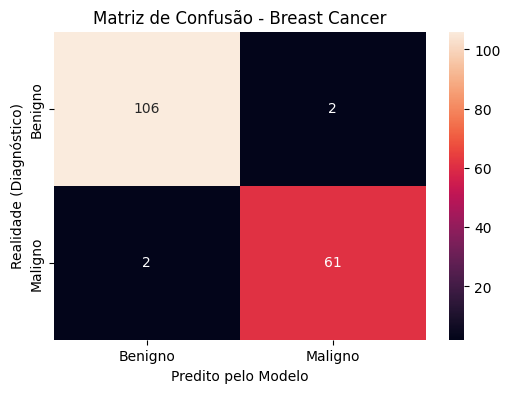

In [9]:
import seaborn as sns

cm = confusion_matrix(y_test, modelo_rbf.predict(X_test_scaled))

# Plotando de forma visual
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Benigno', 'Maligno'], yticklabels=['Benigno', 'Maligno'])
plt.xlabel('Predito pelo Modelo')
plt.ylabel('Realidade (Diagnóstico)')
plt.title('Matriz de Confusão - Breast Cancer')
plt.show()

No final da análise, foi gerada a **Matriz de Confusão** do modelo **SVM (Kernel RBF)**

**Acertos (Diagonal):**
    * No topo à esquerda: Pacientes saudáveis que o modelo disse que estavam OK.
    * No fundo à direita: Pacientes com câncer que o modelo identificou.
      
* **Erros:**
    * **Falsos Positivos:** O modelo previu câncer em um paciente saudável
    * **Falsos Negativos:** **O erro mais grave.** O paciente está doente, mas o modelo disse que ele está saudável.

**Análise:**
Buscamos o menor número possível de **Falsos Negativos**. Com uma acurácia de 98%, este modelo demonstra ser uma ferramenta de **auxílio** ao diagnóstico.